# Strategy comparison: which phasing shape/intensity wins?

**Question:** which phasing shape and intensity wins across variance, bias
and identifiability, not just cost? Folds the old
`10_benefit_table.ipynb`/`11_phasing_strategy.ipynb` pair into one --
`DiscoveryReport` already sweeps a lever grid and scores every candidate on
these exact axes (see `_pick_winner` in `_discovery_report.py`), so this
notebook drives that class directly rather than reimplementing bias/
variance/identifiability measurement by hand the way the old notebooks had
to (before `DiscoveryReport` existed).

Uses `DiscoveryReport`'s own default lever grid (`levers=` left unset) --
the full `_default_levers` sweep: unphased, then +/-20/40/60/80% at each
of uniform/edge-balanced/seesaw, then three contiguous-Blackout settings
(dark=1 through dark=4/prob=1.0). 16 candidates on the same canonical
scenario as notebook 01. Session 56 widened this grid (see NOTES.md,
SCOPE.md build-order item 7) after finding the pre-session-56 grid never
actually exercised Blackout's stronger settings -- reading `report.
levers_` here rather than hand-copying a list means this notebook can't
drift out of sync with `_default_levers` again the way the old
`notebooks/archive/11_phasing_strategy.ipynb` did.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from how_wrong_is_your_mmm import DiscoveryReport, simulate_spend
from how_wrong_is_your_mmm._dgp import channel_contributions
from how_wrong_is_your_mmm._discovery_report import _safe_improvement

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Same four channels/economics as notebooks 01/02/03/04.
CHANNELS = ["tv", "meta", "search_generic", "tiktok"]
TRUE_MARGINAL_RETURNS = {"tv": 0.5, "meta": 1.0, "search_generic": 1.5, "tiktok": 1.2}
TRUE_SATURATION = {"tv": 0.60, "meta": 0.75, "search_generic": 0.90, "tiktok": 0.70}
TRUE_ADSTOCK = {"tv": 0.50, "meta": 0.30, "search_generic": 0.10, "tiktok": 0.20}

history_df = simulate_spend(
    n_obs=208, correlation=0.7, channels=CHANNELS, seed=0, start_date="2019-01-07"
)
plan_df = simulate_spend(
    n_obs=52, correlation=0.7, channels=CHANNELS, seed=1, start_date="2023-01-09"
)

report = DiscoveryReport(
    history_df=history_df,
    plan_df=plan_df,
    true_marginal_returns=TRUE_MARGINAL_RETURNS,
    saturation=TRUE_SATURATION,
    adstock=TRUE_ADSTOCK,
    # levers left unset -- this is _default_levers(CHANNELS), read back
    # below rather than hand-copied, so this notebook tracks the source.
)
# Reduced sim counts for notebook speed, same convention as notebook 01 --
# bump these for numbers going into the live report/overview.html for real.
report.fit(n_sims=20, n_phasing_seeds=3, id_n_sims=8)
LEVER_ORDER = [label for label, *_ in report.levers_]
print(f"winner: {report.winner_}")
print(f"{len(LEVER_ORDER)} candidates: {LEVER_ORDER}")

winner: Blackout (dark=4, prob=1.0)
24 candidates: ['unphased', '+/-20% (uniform)', '+/-20% (edge, balanced)', '+/-20% (seesaw)', '+/-40% (uniform)', '+/-40% (edge, balanced)', '+/-40% (seesaw)', '+/-60% (uniform)', '+/-60% (edge, balanced)', '+/-60% (seesaw)', '+/-80% (uniform)', '+/-80% (edge, balanced)', '+/-80% (seesaw)', '+/-20% (redistribute + edge)', '+/-40% (redistribute + edge)', '+/-60% (redistribute + edge)', '+/-80% (redistribute + edge)', '+/-20% (month step)', '+/-40% (month step)', '+/-60% (month step)', '+/-80% (month step)', 'Blackout (dark=1)', 'Blackout (dark=3, prob=0.8)', 'Blackout (dark=4, prob=1.0)']


## The comparison table

Three reliability columns straight from `report.summary()` -- the exact
report-wide (mean-across-channel) criterion `_pick_winner` itself scores
levers on, so this is provably the same evidence a live report's winner is
chosen from, not a fresh computation. Cost is not part of `summary()`, so
it is added the same way `_discovery_report.py`'s own `_render_html`
computes it for the Appendix: `channel_contributions` on history + each
lever's own schedule, compared against the unphased truth.

In [2]:
combined_unphased = pd.concat([report.history_df, report.plan_df])
true_contributions = channel_contributions(
    combined_unphased,
    report.true_marginal_returns,
    report.saturation,
    report.adstock,
    report.reference_spend_,
)
true_revenue = {
    ch: float(true_contributions[ch].iloc[-len(report.plan_df) :].sum())
    for ch in CHANNELS
}

cost_pct = {}
for label in LEVER_ORDER:
    lever_contributions = channel_contributions(
        pd.concat([report.history_df, report.schedules_[label]]),
        report.true_marginal_returns,
        report.saturation,
        report.adstock,
        report.reference_spend_,
    )
    lever_revenue = {
        ch: float(lever_contributions[ch].iloc[-len(report.plan_df) :].sum())
        for ch in CHANNELS
    }
    cost_pct[label] = 100 * float(
        np.mean(
            [_safe_improvement(true_revenue[ch], lever_revenue[ch]) for ch in CHANNELS]
        )
    )

table = report.summary().set_index("lever").loc[LEVER_ORDER]
table["cost_pct"] = pd.Series(cost_pct)
table = table.rename(
    columns={
        "mean_variance_cv": "variance: CV",
        "mean_abs_bias_pct": "bias: |%|",
        "identifiability_valley_pct": "identifiability: valley %",
        "cost_pct": "cost: revenue given up %",
    }
)[
    [
        "variance: CV",
        "bias: |%|",
        "identifiability: valley %",
        "cost: revenue given up %",
        "is_winner",
    ]
]
pd.set_option("display.width", 200)
print(table.round(3).to_string())

                              variance: CV  bias: |%|  identifiability: valley %  cost: revenue given up %  is_winner
lever                                                                                                                
unphased                             0.195     28.359                     41.373                     0.000      False
+/-20% (uniform)                     0.184     28.658                     40.990                     0.045      False
+/-20% (edge, balanced)              0.169     25.839                     40.111                     0.129      False
+/-20% (seesaw)                      0.177     25.096                     39.207                     0.117      False
+/-40% (uniform)                     0.162     28.720                     38.025                     0.180      False
+/-40% (edge, balanced)              0.130     22.626                     32.755                     0.583      False
+/-40% (seesaw)                      0.149     21.382   

## Impact vs unphased, and a picture

`variance`/`bias`/`identifiability` below are `_pick_winner`'s own
improvement-over-unphased fractions (lower raw score is better for all
three), so "biggest bar" means "most improved," matching the winner
selection exactly. Cost has no unphased row -- there is nothing to compare
a zero-deviation plan's revenue against.

                              variance % improved  bias % improved  identifiability % improved  cost: revenue given up %
lever                                                                                                                   
+/-20% (uniform)                              5.9             -1.1                         0.9                       0.0
+/-20% (edge, balanced)                      13.4              8.9                         3.1                       0.1
+/-20% (seesaw)                               9.2             11.5                         5.2                       0.1
+/-40% (uniform)                             16.9             -1.3                         8.1                       0.2
+/-40% (edge, balanced)                      33.6             20.2                        20.8                       0.6
+/-40% (seesaw)                              23.8             24.6                        19.2                       0.5
+/-60% (uniform)                

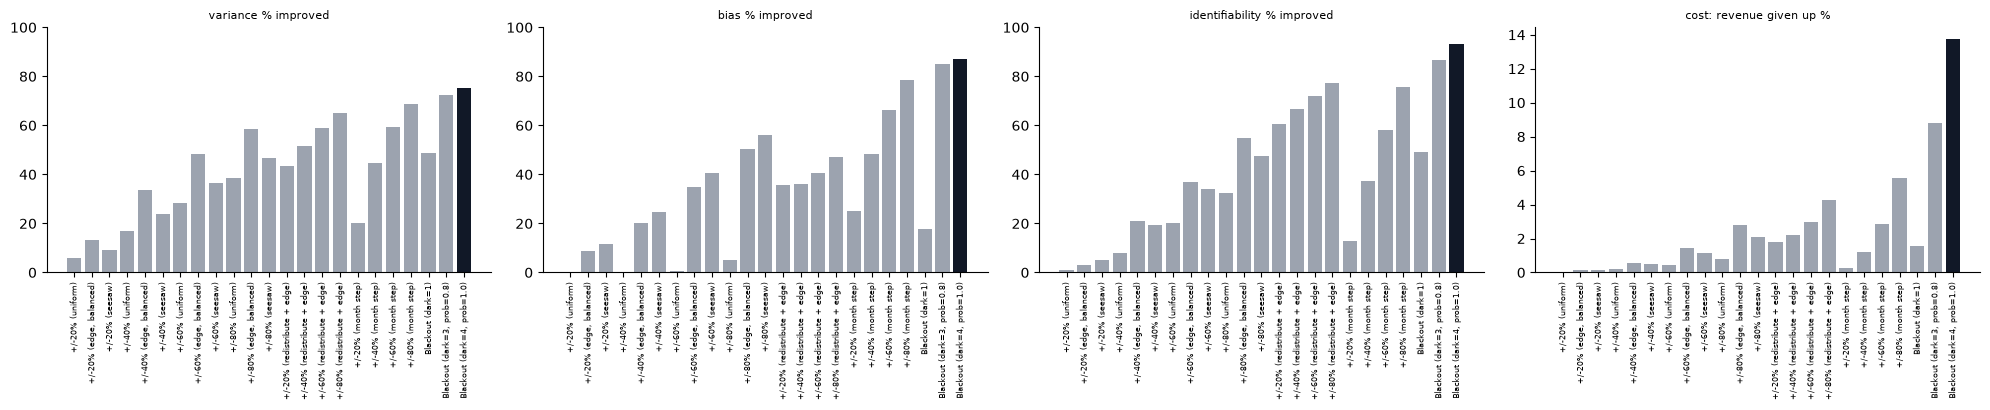

In [3]:
baseline_scores = report.results_["unphased"]["scores"]
impact_rows = []
for label in LEVER_ORDER[1:]:
    scores = report.results_[label]["scores"]
    impact_rows.append(
        {
            "lever": label,
            "variance % improved": 100
            * _safe_improvement(baseline_scores["variance"], scores["variance"]),
            "bias % improved": 100
            * _safe_improvement(baseline_scores["bias"], scores["bias"]),
            "identifiability % improved": 100
            * _safe_improvement(
                baseline_scores["identifiability"], scores["identifiability"]
            ),
            "cost: revenue given up %": cost_pct[label],
        }
    )
impact = pd.DataFrame(impact_rows).set_index("lever")
print(impact.round(1).to_string())

# Generic colouring for an arbitrary-length lever grid (16 candidates,
# vs the old hand-picked 5 a fixed label->colour dict could name): the
# winner in the report's own "recommended" navy, everything else a
# neutral grey, so the chart scales with _default_levers without needing
# a colour entry added by hand every time a candidate is added.
WINNER_COLOR = "#111827"
OTHER_COLOR = "#9ca3af"
bar_colors = [
    WINNER_COLOR if lv == report.winner_ else OTHER_COLOR for lv in impact.index
]

panels = ["variance % improved", "bias % improved", "identifiability % improved"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, col in zip(axes[:3], panels):
    vals = impact[col]
    ax.bar(vals.index, vals, color=bar_colors)
    ax.set_title(col, fontsize=8)
    ax.tick_params(axis="x", rotation=90, labelsize=6)
    ax.set_ylim(0, 100)
ax = axes[3]
vals = impact["cost: revenue given up %"]
ax.bar(vals.index, vals, color=bar_colors)
ax.set_title("cost: revenue given up %", fontsize=8)
ax.tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

## Bringing it together

**`Blackout (dark=4, prob=1.0)` wins the sweep outright, but is not
recommended.** It beats every other candidate on all three rigor axes at
once -- variance improves 75.4% vs `edge+balanced+80%`'s 58.7%, bias
87.0% vs 50.3%, identifiability 93.4% vs 54.7% -- and `DiscoveryReport`
picks it for exactly that reason (`_pick_winner`'s dominance check finds
one candidate on top of every axis, not a coin flip). But `_pick_winner`
scores rigor only, never operational feasibility, and dark=4/prob=1.0
forces whichever single week survives each month to carry roughly 3-4x
its normal budget to make that month's total whole. No media buyer would
actually schedule that, whatever the identifiability gain -- a sweep
winner and a recommendation are not automatically the same thing. The
practical fix is a smarter *lever*, not a smarter sweep: something with
Blackout's annual discipline but sized so no single week absorbs a whole
dark run's spend, and built to disturb a channel's normal pacing as
little as possible outside its own deliberate move (an early sketch:
each channel gets a capped number of blackout months a year, funding a
capped number of modest up-months, plus small randomised nudges spread
across the remaining months). Not designed yet -- see `SCOPE.md`.

**The cost is real and roughly 5x `edge+balanced+80%`'s.** 13.75% of
plan-period revenue given up under the assumed saturation curves, against
2.77% for `edge+balanced+80%` -- on top of being undeployable as a single
week's spike, the reliability gain also isn't free.

**`Blackout (dark=3, prob=0.8)` has the same deployability problem, just
less extreme.** 72.5% / 85.0% / 86.6% on variance/bias/identifiability at
8.8% cost -- still forces real spend spikes on the surviving weeks each
month, just smaller ones than dark=4. Worth keeping in mind as a design
reference point, not as something to hand a client today.

**`seesaw` confirms session 56's read: a genuine trade-off against
`edge`, not a strict win.** At 80%, `seesaw` beats `edge, balanced` on
bias (56.2% vs 50.3%) and costs less (2.1% vs 2.8%), but loses on
variance (46.5% vs 58.7%) and identifiability (47.4% vs 54.7%) -- worth
offering as an alternative shape, not a replacement.

**`edge, balanced` remains today's practical recommendation.** It is the
strongest *deployable* shape at every intensity, and the number quoted
throughout `docs/overview.html` and the README. Nothing here changes
that: `uniform` and `seesaw` never beat it on more than one or two axes
at matched intensity, and Blackout's stronger settings win on paper only
by proposing a schedule no one would actually run.
